# Evaluate conditions (between statements)
- LOG: TH500
- K: 5


In [1]:
%load_ext autoreload
%autoreload 2
import os
os.chdir('../..')

from sqlcompletions.evaluator import run_n_tests, create_tests
from sqlcompletions import bandits
from sqlcompletions.sqlparser import schema

CPU times: user 63.5 ms, sys: 50.7 ms, total: 114 ms
Wall time: 30.2 s


,Test,MAP@K,Execution Time
4,Best Bin,0.29,0.14
1,UCB,0.20,0.06
2,pUCB,0.19,0.07
3,Thompson Sampling,0.18,0.08
0,Egreedy,0.17,0.05
5,Most popular,0.17,0.46


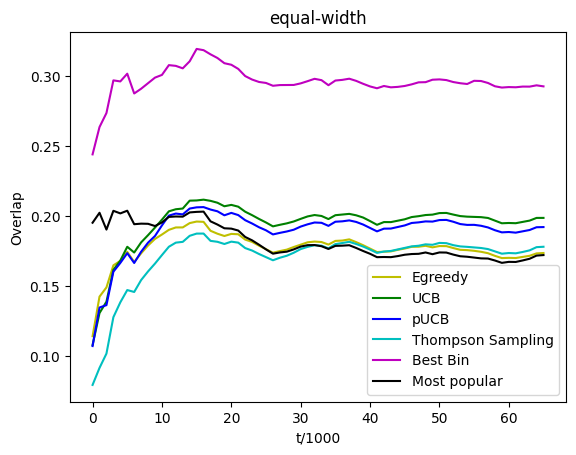

In [2]:
%%time
db = schema(db_stats=True,discretization_method="equal-width")
tests = create_tests(algorithms=["egreedy","thompson", "ucb", "pucb","popularRegion","all"], clause=3, top_k = 5 , db = db , th = 500 )
run_n_tests(tests,"equal-width", ylabel = "Overlap").results

# Equal Height (Frequency)

CPU times: user 52.5 ms, sys: 43.8 ms, total: 96.3 ms
Wall time: 41.7 s


,Test,MAP@K,Execution Time
4,Best Bin,0.51,0.14
1,UCB,0.38,0.06
2,pUCB,0.37,0.07
3,Thompson Sampling,0.35,0.08
5,Most popular,0.35,0.66
0,Egreedy,0.33,0.05


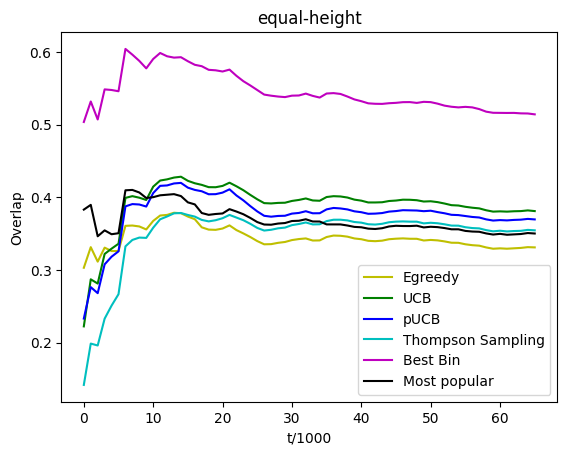

In [3]:
%%time
db = schema(db_stats=True, discretization_method="equal-height")
tests = create_tests(algorithms=["egreedy","thompson", "ucb", "pucb","popularRegion","all"], clause=3, top_k = 5 , db = db , th = 500 )
run_n_tests(tests,"equal-height", ylabel = "Overlap").results

# K-Means

CPU times: user 64 ms, sys: 44.6 ms, total: 109 ms
Wall time: 7.29 s


,Test,MAP@K,Execution Time
0,Best Bin,0.46,0.03
2,UCB,0.40,0.03
3,Thompson Sampling,0.39,0.05
4,pUCB,0.39,0.05
1,Egreedy,0.37,0.03
5,Most popular,0.36,0.08


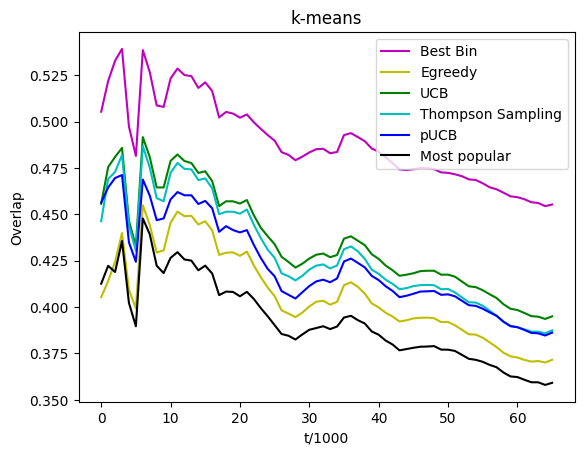

In [2]:
%%time

db = schema(db_stats=True, discretization_method="kmeans")
tests = create_tests(algorithms=["egreedy","thompson", "ucb", "pucb","popularRegion","all"], clause=3, top_k = 5 , db = db , th = 500 )
run_n_tests(tests,"k-means", ylabel = "Overlap").results